# 8-Channel MTS example test
---

This notebook is based on Xilinx [RFSoC-MTS](https://github.com/Xilinx/RFSoC-MTS/blob/main/boards/ZCU208/notebooks/rfsocMTS.ipynb).

This overlay provides one DAC player memory that is broadcast to multiple RF DAC tiles. DACs in use are Tiles 228 and 229. Tile 230, while enabled, only shares the reference 4GHz to Tiles 228 and 229.  ADC tiles 224 and 225 capture to internal memories.  ADC tile 225 channel 1 stores to the PL DRAM via DMA.  A simplified block diagram is presented below.

The following results were captured when looping back DAC 0 -> ADC 0, and DAC 2 -> ADC 2.


### Preparation from a PYNQ 3.0.1 image:

1. Patch xrfdc to version 2.0 for enabling MTS following the [installation script](https://github.com/Xilinx/RFSoC-MTS/blob/main/install.sh).
2. Install `xrfclk` PICS files for testing frequency settings: 4 Gsps for DAC and ADC.
    ```
    sudo cp RFSoC-MTS/boards/ZCU208/xrfclk/* /usr/local/share/pynq-venv/lib/python3.10/site-packages/xrfclk/
    ```
3. Expect the following files in `/home/xilinx/jupyter_notebooks/RFSoC-MTS/rfsoc_mts`:
    * `ddr4.dtbo`: built by `install.sh` via device tree compiler
    * `mts.ZCU208.bit` and `mts.ZCU208.hwh` after executing `download_overlays()` in the follwing step.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [1]:
import mts_8ch
import os
#bitpath = os.path.join(os.getcwd(), "mts_8ch.bit")
# TESTING
bitpath = os.path.join(os.getcwd(), "mts_8ch_alt.bit")
ol = mts_8ch.mtsOverlay(bitpath)

ip transmitter/hier_dac_play/axi_bram_ctrl_0 has addr_range = 32768
ip transmitter/hier_dac_cap/axi_bram_ctrl_0 has addr_range = 32768
ip receiver/chan0_I/axi_bram_ctrl_0 has addr_range = 32768
ip receiver/chan0_Q/axi_bram_ctrl_0 has addr_range = 32768
ip receiver/chan1_I/axi_bram_ctrl_0 has addr_range = 32768
ip receiver/chan1_Q/axi_bram_ctrl_0 has addr_range = 32768
ip receiver/chan2_I/axi_bram_ctrl_0 has addr_range = 32768
ip receiver/chan2_Q/axi_bram_ctrl_0 has addr_range = 32768
ip receiver/chan3_I/axi_bram_ctrl_0 has addr_range = 32768
ip receiver/chan3_Q/axi_bram_ctrl_0 has addr_range = 32768
ip receiver/chan4_I/axi_bram_ctrl_0 has addr_range = 32768
ip receiver/chan4_Q/axi_bram_ctrl_0 has addr_range = 32768
ip receiver/chan5_I/axi_bram_ctrl_0 has addr_range = 32768
ip receiver/chan5_Q/axi_bram_ctrl_0 has addr_range = 32768
ip receiver/chan6_I/axi_bram_ctrl_0 has addr_range = 32768
ip receiver/chan6_Q/axi_bram_ctrl_0 has addr_range = 32768
ip receiver/chan7_I/axi_bram_ctrl_0 has

In [3]:
def print_attrs(obj, all=False):
    print("Attrs:")
    for attr in dir(obj):
        if all or (not attr.startswith("_")):
            print("  " + attr)

def print_dict(dd, indent=0, depth=-1):
    ind = " "*indent
    for key, val in dd.items():
        print("{}{}:".format(ind, key), end="")
        if hasattr(val, "keys"):
            if depth == 0:
                print(" dict len {}".format(len(val)))
            else:
                print()
                print_dict(val, indent+2, depth-1)
        else:
            print(" {}".format(val))

def print_dicts(obj, depth=-1):
    for dd, name in ((obj.ip_dict, "ip_dict"), (obj.mem_dict, "mem_dict"), (obj.hierarchy_dict, "hierarchy_dict")):
        print(name + ":")
        print_dict(dd, indent=2, depth=depth)

# ILA + DebugBridge

In [4]:
from pynq.lib import DebugBridge
from pynqutils.runtime.repr_dict import ReprDict
base = 0x800B0000
high = 0x800BFFFF
dd = {
    "phys_addr": base,
    "addr_range": high-base+1,
    "fullpath": "/debug_bridge_0",
    "parameters": {},
}
bridge = DebugBridge(ReprDict(dd))

In [5]:
bridge.start_xvc_server()

XVC server started


In [53]:
if bridge.serverThread is not None:
    bridge.stop_xvc_server()

Client at ('192.168.2.1', 42004) disconnected by stop...
XVC server stopped


In [52]:
if bridge.serverThread is not None:
    print(bridge.serverThread.serverPort)
else:
    print("Server is stopped")

2542


# Diagnostic Slow Readback

In [5]:
from pynq import MMIO
class DiagReadback():
    def __init__(self, baseAddr, num_regs=19):
        self._base = baseAddr
        mmios = [MMIO(baseAddr + 4*n) for n in range(num_regs)]
        # ========================= Memory Map =================================
        self._mmios_first_tdata = mmios[:8]
        self._mmios_last_tdata = mmios[8:16]
        self._mmios_trigger_counter = mmios[16:17]
        self._mmios_rollover_counter = mmios[17:18]
        self._mmios_tvalid_counter = mmios[18:19]

    def get_first_tdata_list(self):
        return [mmio.read() for mmio in self._mmios_first_tdata]

    def get_last_tdata_list(self):
        return [mmio.read() for mmio in self._mmios_last_tdata]

    def get_trigger_counter(self):
        return self._mmios_trigger_counter[0].read() & 0xff

    def get_rollover_counter(self):
        return self._mmios_rollover_counter[0].read() & 0xff

    def get_tvalid_counter(self):
        return self._mmios_tvalid_counter[0].read() & 0xff

In [26]:
#print_dicts(ol, depth=0)

Connection from : ('192.168.2.1', 60648)


In [7]:
#dd = ol.ip_dict["hier_dac_cap/diag_readback_0"]
#addr = int(dd["parameters"].get("C_BASEADDR"), 16)
addr = 0xA0050000
rbk = DiagReadback(addr)

In [8]:
print(rbk.get_trigger_counter())
print(rbk.get_rollover_counter())
print(rbk.get_tvalid_counter())
fdl = rbk.get_first_tdata_list()
#ldl = rbk.get_last_tdata_list()
for data in fdl:
    print("  0x{:08x}".format(data))

0
0
0
  0x00000000
  0x00000000
  0x00000000
  0x00000000
  0x00000000
  0x00000000
  0x00000000
  0x00000000


In [27]:
#print_dict(ol.mem_dict["transmitter/hier_dac_play/axi_bram_ctrl_0"], depth=1)

In [4]:
ol.is_loaded()

True

In [3]:
from pynq import Clocks

print(f'CPU:   {Clocks.cpu_mhz:10.3f} MHz')
print(f'FCLK0: {Clocks.fclk0_mhz:10.3f} MHz')
print(f'FCLK1: {Clocks.fclk1_mhz:10.3f} MHz')
print(f'FCLK2: {Clocks.fclk2_mhz:10.3f} MHz')
print(f'FCLK3: {Clocks.fclk3_mhz:10.3f} MHz')

CPU:     1199.988 MHz
FCLK0:     99.999 MHz
FCLK1:     99.999 MHz
FCLK2:     99.999 MHz
FCLK3:     99.999 MHz


# Generate Waveforms for Loopback
 This overlay uses a single waveform memory that is broadcast to multiple DAC tiles.
### Prepare the DAC Memory
The cell below generates examples waveforms and has customizable paramters.  For example, one can adjust the center frequency, Fc, and re-generate a sinewave.

In [5]:
from scipy.signal import chirp
from scipy.signal import sawtooth
from scipy.signal import gausspulse

n_adcs = 8
DAC_SR = mts_8ch.ZCU208_LMX_FREQ*1.0e6  # Sample rate of DACs and ADCs is 4.0 GHz
ADC_SR = mts_8ch.ZCU208_LMX_FREQ*1.0e6
Fc = 100.0E6 # Set center frequency of waveform to 100.0 MHz
Fe = 800.0E6 # maximum frequency of chirp at end of record
DAC_Amplitude = 16383.0 # 14bit DAC +16383/-16384
# DAC_Amplitude = 100.0 # 14bit DAC +16383/-16384
n_samples = ol.dac_player.size
X_axis = (1/DAC_SR) * np.arange(n_samples)

In [52]:
DAC_Amplitude = float(0xd0c)

In [6]:
# generate some basic waveforms
DAC_sinewave = DAC_Amplitude * np.cos(2*np.pi*Fc*X_axis)
DAC_sawtooth = DAC_Amplitude * sawtooth(2 * np.pi * Fc * X_axis)
DAC_chirp = DAC_Amplitude * chirp(np.arange(0, ol.dac_player.shape[0])/DAC_SR,
                                  f0=Fc, f1=Fe, t1=(ol.dac_player.shape[0]/DAC_SR), 
                                  phi=0.0, method='linear')
DAC_const = DAC_Amplitude * np.ones((1,len(ol.dac_player)), dtype=np.int16)

In [59]:
# ol.dac_player[:] = np.int16(DAC_sinewave)
# ol.dac_player[:] = np.int16(DAC_sawtooth)
# ol.dac_player[:] = np.int16(DAC_chirp)
ol.dac_player[:] = DAC_const

In [7]:
ol.dac_player[:] = np.int16(DAC_sinewave)

In [49]:
for n in range(len(DAC_test)):
    ol.dac_player[n] = DAC_test[n]

In [85]:
[hex(x & 0xffff) for x in DAC_test[0:9]]

['0x3fff',
 '0x3ffc',
 '0x3ff6',
 '0x3fec',
 '0x3fde',
 '0x3fcc',
 '0x3fb6',
 '0x3f9c',
 '0x3f7d']

In [16]:
print([hex(x) for x in ol.dac_capture[:4]])

['0x0', '0x0', '0x0', '0x0']


## Capture DAC Waveform to Internal Memory
The DAC waveform is saved to an internal memory for verification purposes.

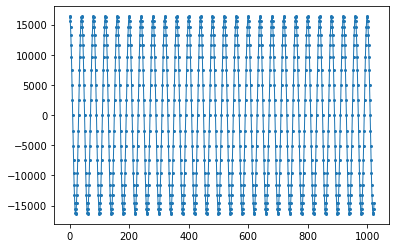

In [8]:
# Verify the contents of the dac_player memory
plt.plot(ol.dac_player[:1024], marker='o', linewidth=1, markersize=2);

In [9]:
import time
def trigger_capture(ol):
    """ Internal loopback of DAC waveform to internal capture mirror"""        
    ol.trig_cap.off()
    #ol.dac_enable.off()
    #ol.dac_enable.on()
    #time.sleep(0.1)
    ol.trig_cap.on() # actually triggers adc[A..C] to capture too
    time.sleep(0.5)
    ol.trig_cap.off()

In [10]:
ol.dac_enable.on()

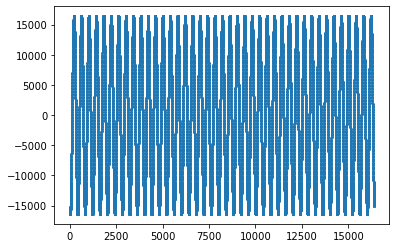

In [14]:
#ol.trigger_capture()
trigger_capture(ol)
plt.plot(ol.dac_capture[:], marker='o', linewidth=1, markersize=2);
#ol.dac_enable.off()

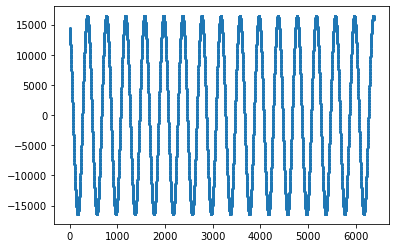

In [19]:
# Confirm frequency by plotting what we expect to be a single period of the sine wave
# period = int(np.ceil(DAC_SR/Fc))
plt.plot(ol.dac_capture[10000:], marker='o', linewidth=1, markersize=2)

In [3]:
print(ol.dac_capture.shape)
print(ol.dac_player.shape)

(16384,)
(16384,)


In [20]:
def stemplot(sample_list, pStart=0, pNumSamples=16, channels=None):
    _fmts = ('rx', 'Co', 'b.', 'g*', 'rx', 'Co', 'b.', 'g*',)
    colors = ('blue', 'brown', 'red', 'orange', 'purple', 'green', 'magenta', 'cyan',
             'blue', 'brown', 'red', 'orange', 'purple', 'green', 'magenta', 'cyan')
    if channels is None:
        channels = range(n_adcs)
    for channel in channels:
        plt.stem(sample_list[channel][pStart:(pStart+pNumSamples)], label=str(channel), linefmt=colors[channel], markerfmt=colors[channel])
        #plt.stem(sample_list[1][pStart:(pStart+pNumSamples)], linefmt='r:', markerfmt='rx')
    plt.tight_layout()
    plt.legend()
    return plt

def gridplot(sample_list, pStart=0, pNumSamples=128, channels=None):
    colors = ('blue', 'brown', 'red', 'orange', 'purple', 'green', 'magenta', 'cyan',
             'blue', 'brown', 'red', 'orange', 'purple', 'green', 'magenta', 'cyan')
    if channels is None:
        channels = range(n_adcs)
    nchan = len(channels)
    plt.subplots(nchan,1)
    for n in range(len(channels)):
        channel = channels[n]
        plt.subplot(nchan, 1, n+1)
        plt.plot(sample_list[channel][pStart:(pStart+pNumSamples)], label=str(channel), color=colors[channel])
    plt.tight_layout()
    plt.legend()
    return plt

# Enable Multi-Tile Synchronization - MTS
With Multi-Tile Synchronization enabled the DAC output and ADC samples are aligned.  This feature of the RFSOC allows coherency across DAC and ADC tiles.  The RF tiles are reset and their internal FIFOs reset via "init_tile_sync" while also testing if the synthesizer clocks are ready.  Once initialized, the "sync_tiles" function begins the synchronization procedure of the tiles. The results are analyzed below.

In [11]:
ol.init_tile_sync()
ol.verify_clock_tree()

In [12]:
ol.sync_tiles()

In [16]:
AlignedCaptureSamples = np.zeros((ol.nadc_mem_total,len(ol.adc_captures[0][0])),dtype=np.int16)
ol.internal_capture(AlignedCaptureSamples)

Plot only the I components

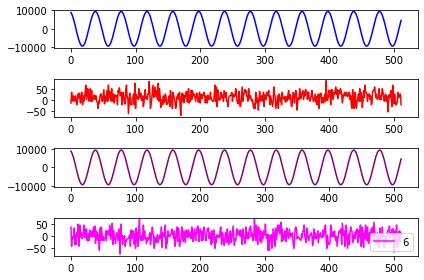

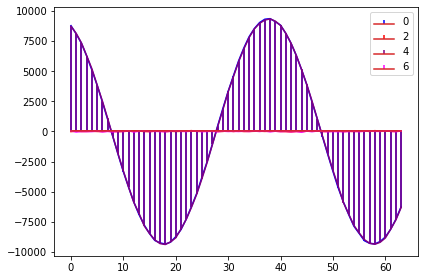

In [18]:
channels=(0,2,4,6)
gridplot(AlignedCaptureSamples, pStart=0, pNumSamples=512, channels=channels).show()
stemplot(AlignedCaptureSamples, pStart=0, pNumSamples=64, channels=channels).show()

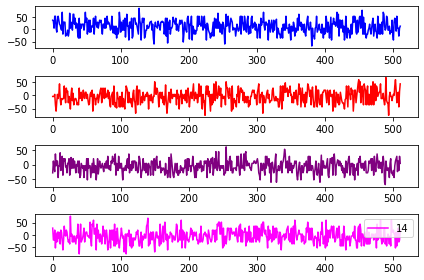

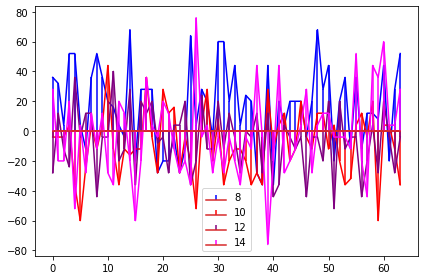

In [21]:
channels=(8,10,12,14)
gridplot(AlignedCaptureSamples, pStart=0, pNumSamples=512, channels=channels).show()
stemplot(AlignedCaptureSamples, pStart=0, pNumSamples=64, channels=channels).show()

---
# Mixer test

zero out dacs

In [47]:
ol.dac_player[:] = np.ones(n_samples, dtype=np.int16) * 32767

In [48]:
ol.dac_player[:] = np.int16(DAC_sinewave)
# ol.dac_player[:] = np.int16(DAC_sawtooth)
#ol.dac_player[:] = np.int16(DAC_chirp)

In [49]:
dac_blocks = [
    ol.xrfdc.dac_tiles[0].blocks[0],
    ol.xrfdc.dac_tiles[0].blocks[2],
    ol.xrfdc.dac_tiles[1].blocks[0],
    ol.xrfdc.dac_tiles[1].blocks[2],
]

adc_blocks = [
    ol.xrfdc.adc_tiles[0].blocks[0],
    ol.xrfdc.adc_tiles[0].blocks[1],
    ol.xrfdc.adc_tiles[1].blocks[0],
    ol.xrfdc.adc_tiles[1].blocks[1],
]

In [50]:
ol.xrfdc.adc_tiles[1].blocks[0].MixerSettings

{'Freq': 0.0,
 'PhaseOffset': 0.0,
 'EventSource': 2,
 'CoarseMixFreq': 16,
 'MixerMode': 3,
 'FineMixerScale': 0,
 'MixerType': 2}

In [51]:
ol.xrfdc.adc_tiles[0].blocks[0].MixerSettings

{'Freq': 0.0,
 'PhaseOffset': 0.0,
 'EventSource': 2,
 'CoarseMixFreq': 16,
 'MixerMode': 3,
 'FineMixerScale': 0,
 'MixerType': 2}

In [52]:
for dac_block in dac_blocks[:2]:
    display(dac_block.BlockStatus)
    display(dac_block.MixerSettings)

{'SamplingFreq': 4.0,
 'AnalogDataPathStatus': 16,
 'DigitalDataPathStatus': 8225,
 'DataPathClocksStatus': 1,
 'IsFIFOFlagsEnabled': 3,
 'IsFIFOFlagsAsserted': 0}

{'Freq': 500.0,
 'PhaseOffset': 0.0,
 'EventSource': 2,
 'CoarseMixFreq': 16,
 'MixerMode': 2,
 'FineMixerScale': 0,
 'MixerType': 2}

{'SamplingFreq': 4.0,
 'AnalogDataPathStatus': 16,
 'DigitalDataPathStatus': 8225,
 'DataPathClocksStatus': 1,
 'IsFIFOFlagsEnabled': 3,
 'IsFIFOFlagsAsserted': 0}

{'Freq': 500.0,
 'PhaseOffset': 0.0,
 'EventSource': 2,
 'CoarseMixFreq': 16,
 'MixerMode': 2,
 'FineMixerScale': 0,
 'MixerType': 2}

In [53]:
import xrfdc

for dac_block in dac_blocks[:2]:
    dac_block.MixerSettings = {
        'Freq': 500,
        'CoarseMixFreq': xrfdc.COARSE_MIX_BYPASS,
        'MixerMode': xrfdc.MIXER_MODE_R2R,
        'MixerType': xrfdc.MIXER_TYPE_COARSE
    }

In [29]:
for dac_block in dac_blocks[:2]:
    dac_block.MixerSettings = {
        'Freq': 500,
        'CoarseMixFreq': xrfdc.COARSE_MIX_BYPASS,
        'MixerMode': xrfdc.MIXER_MODE_C2R,
        'MixerType': xrfdc.MIXER_TYPE_FINE
    }

In [42]:
for adc_block in adc_blocks:
    adc_block.MixerSettings = {
        'Freq': 0,
        'EventSource': xrfdc.EVNT_SRC_TILE,
        'CoarseMixFreq': xrfdc.COARSE_MIX_OFF,
        'MixerMode': xrfdc.MIXER_MODE_R2C,
        'FineMixerScale': xrfdc.MIXER_SCALE_AUTO,
        # 'MixerType': xrfdc.MIXER_TYPE_COARSE
        'MixerType': xrfdc.MIXER_TYPE_FINE
    }

In [43]:
for adc_block in adc_blocks:
    adc_block.MixerSettings = {
        'Freq': 0,
        'EventSource': xrfdc.EVNT_SRC_TILE,
        'CoarseMixFreq': 16,
        'MixerMode': 4,
        'FineMixerScale': xrfdc.MIXER_SCALE_AUTO,
        # 'MixerType': xrfdc.MIXER_TYPE_COARSE
        'MixerType': 1
    }

In [44]:
for adc_block in adc_blocks[:1]:
    adc_block.MixerSettings = {
        'Freq': 100,
        'EventSource': xrfdc.EVNT_SRC_TILE,
        'CoarseMixFreq': xrfdc.COARSE_MIX_SAMPLE_FREQ_BY_FOUR,
        'MixerMode': xrfdc.MIXER_MODE_R2C,
        'FineMixerScale': xrfdc.MIXER_SCALE_AUTO,
        'MixerType': xrfdc.MIXER_TYPE_COARSE
    }

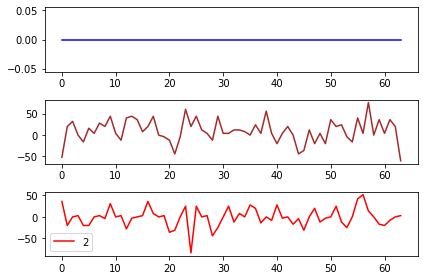

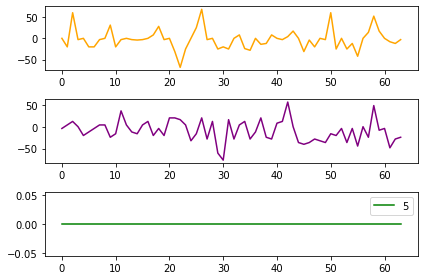

In [58]:
ol.internal_capture(AlignedCaptureSamples)
gridplot(AlignedCaptureSamples, pStart=0, pNumSamples=64, channels=(0,1,2)).show()
gridplot(AlignedCaptureSamples, pStart=0, pNumSamples=64, channels=(3,4,5)).show()
# plt.plot(AlignedCaptureSamples[0][128])

In [14]:
import pynq

In [15]:
dir(pynq)

['Bitstream',
 'Clocks',
 'DataRecorder',
 'DefaultHierarchy',
 'DefaultIP',
 'Device',
 'DeviceTreeSegment',
 'GPIO',
 'Interrupt',
 'MMIO',
 'Overlay',
 'PL',
 'Register',
 'UioController',
 'UnsupportedConfiguration',
 '_3rdparty',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__git_id__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'allocate',
 'bitstream',
 'buffer',
 'devicetree',
 'get_rails',
 'gpio',
 'interrupt',
 'lib',
 'metadata',
 'mmio',
 'overlay',
 'pl',
 'pl_server',
 'pmbus',
 'ps',
 'registers',
 'uio']

In [16]:
pynq.__version__

'3.0.1'